# 01 · PyTorch Basics

Following the PyTorch **Learn the Basics** tutorial. Type the code myself, never copy-paste. Notes go in `notes.md`.

In [1]:
import torch
print(torch.__version__)
import numpy as np
from torch import nn

2.11.0+cpu


## 1. Tensors

In [2]:
arr=np.array([[1, 2, 3], [4, 5, 6]])
tensor=torch.from_numpy(arr)

## 2. Datasets & DataLoaders

In [3]:
from torchvision import datasets,transforms
transform=transforms.Compose([transforms.ToTensor()])
trainset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.0MB/s]


In [ ]:
from torch.utils.data import DataLoader
trainloader = DataLoader(trainset,shuffle=True,batch_size=64)
testloader=DataLoader(testset,shuffle=False,batch_size=64)


In [22]:
epochs=5
train_loss=[]
test_acc=[]

## 3. Build the Model (`nn.Module`)

In [5]:
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten=torch.nn.Flatten()
        self.linear_relu_stack=torch.nn.Sequential(nn.Linear(28*28,64),nn.ReLU(),nn.Linear(64,10),nn.ReLU(),nn.Linear(10,10))
    def forward(self,x):
        x=self.flatten(x)
        logits=self.linear_relu_stack(x)
        return logits




## 4. Autograd

In [6]:
model=MyModel()
images,labels=next(iter(trainloader))
print(model(images).shape)
print(labels.shape)

torch.Size([64, 10])
torch.Size([64])


In [7]:
logits=model(images)
loss_fn=torch.nn.CrossEntropyLoss()
loss=loss_fn(logits,labels)


In [8]:
import torch.optim as optim
optimizer=optim.Adam(model.parameters(),lr=0.001)
print(model.linear_relu_stack[0].weight.grad)

None



## 5. Training Loop (Optimization)


## 6. Save & Load the Model

In [25]:
for epoch in range(epochs):
    for images,labels in trainloader:
        logits=model(images)
        loss=loss_fn(logits,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(loss.item())
    model.eval()
    with torch.no_grad():
        count=0
        total=0
        for image ,labels in testloader:
            logits=model(image)
            pred=logits.argmax(dim=1)
            count=count+((pred==labels).sum().item())
            total=total+len(labels)
    train_loss.append(loss.item())
    test_acc.append(count/total)

0.4264114201068878
0.12113393843173981
0.24126647412776947
0.3169969916343689
0.32727861404418945


In [26]:
print(count/total)

0.8627


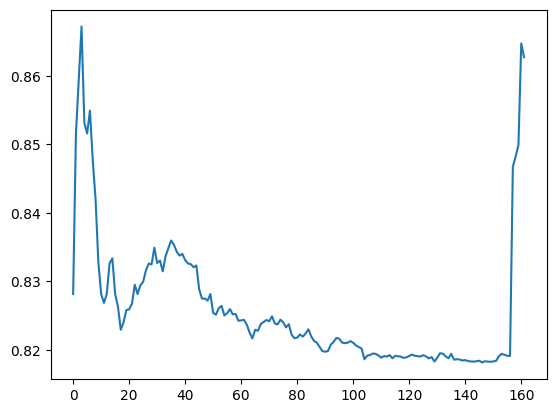

In [27]:
import matplotlib.pyplot as plt
plt.plot(test_acc)

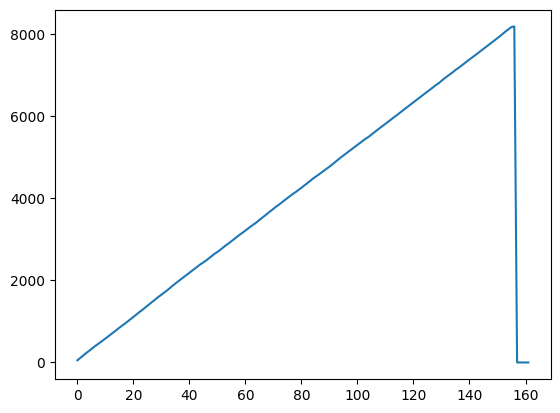

In [28]:
plt.plot(train_loss)

In [29]:
torch.save(model.state_dict(),"fashion_model.pth")

In [31]:
loaded_model=MyModel()
loaded_model.load_state_dict(torch.load("fashion_model.pth"))
loaded_model.eval()

MyModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=10, bias=True)
  )
)